# Hola Yaya!

Mi nombre es David Bautista, soy code reviewer de TripleTen y voy a revisar el proyecto que acabas de desarrollar.

Cuando vea un error la primera vez, lo señalaré. Deberás encontrarlo y arreglarlo. La intención es que te prepares para un espacio real de trabajo. En un trabajo, el líder de tu equipo hará lo mismo. Si no puedes solucionar el error, te daré más información en la próxima ocasión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres.**

¿Cómo lo voy a hacer? Voy a leer detenidamente cada una de las implementaciones que has llevado a cabo para cumplir con lo solicitado. Verás los comentarios de esta forma:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Si todo está perfecto.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>


<div class="alert alert-block alert-danger">
    
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
    
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma: 

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
</div>

¡Empecemos!

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

# Comentario General

Hola, Yaya, te felicito por el desarrollo del proyecto hasta el momento. Ahora bien, he dejado diferentes comentarios para que los puedas revisar y tener en cuenta para la siguiente entrega. </div>

# Descripción del Proyecto

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes.
¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas. Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.do.


En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese. Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.


Tienes que:
Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
Analizar los factores que más impactan la pérdida.
Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
identificar a los grupos objetivo;
sugerir medidas para reducir la rotación;
describir cualquier otro patrón que observes con respecto a la interacción con los clientes.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Excelente, yaya, Muy buen trabajo estructurando esta sección de introducción para el desarrollo del proyecto. </div>

### Paso 1. Descargar los datos

Model Fitness te aportó archivos CSV que contienen los datos sobre la cancelación de un mes en concreto e información del mes que lo precedía. 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
from scipy import stats
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo importando las librerías necesarias para el desarrollo del proyecto. </div>

In [8]:
gym = pd.read_csv('/datasets/gym_churn_us.csv')

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo cargando el dataset necesario para el desarrollo del proyecto.. </div>

### Paso 2. Llevar a cabo el análisis exploratorio de datos (EDA)

In [9]:
#Se define EDA función para explorar los datos.

def EDA(datos):
    print("Primeras Filas")
    print(datos.head())
    print()
    print("Datos Generales")
    print(datos.info())
    print()
    print("Revision de Datos Ausentes")
    print(datos.isna().sum())
    print()
    print("Filas Duplicadas")
    print(datos.duplicated().sum())

In [10]:
EDA(gym)

Primeras Filas
   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_curre

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo estructurando y aplicando la función para realizar un análisis exploratorio inicial del contenido del dataset. </div>

**Observa el dataset: ¿contiene alguna característica ausente? Estudia los valores promedio y la desviación estándar (utiliza el método describe())**

In [11]:
#Verificar valores ausentes
print("Valores ausentes por columna")
print(gym.isnull().sum())

Valores ausentes por columna
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo identificando la cantidad de valores nulos dentro de cada una de las columnas del dataset. </div>

In [12]:
#Estadisticas descriptivas del dataset
print("\nEstadísticas descriptivas")
gym.describe()


Estadísticas descriptivas


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
Se pudo observar que no se tiene valores ausentes, que la proporción de cancelación es de alrededor del 26.5%, la edad promedio es 29 años, la frecuencia promedio de visitas es 1.88 veces por semana en total y 1.76 veces en el mes actual. El tiempo de vida del usuario promedio es de 3.72 meses pero con usuarios que llevan hasta 31 meses. Los contratos varian de 1 a 12 meses, con una media de 4.68 meses.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Excelente, buen trabajo desplegando el método ``describe()`` y estudiando los resultados.  </div>

**Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron (utiliza el método groupby()).**

In [13]:
#Calcular los valores medios agrupados por Churn (0 = se quedó, 1 = canceló), valores medios entre los clientes que se quedaron y los que cancelaron
gruoped_means = gym.groupby("Churn").mean()
print("\nValores medios por grupo de cancelación")
gruoped_means


Valores medios por grupo de cancelación


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Excelente, buen trabajo estructurando la tabla agrupada para estudiar los valores medios de las características sujetos al estado de cancelación de la membresía.   </div>

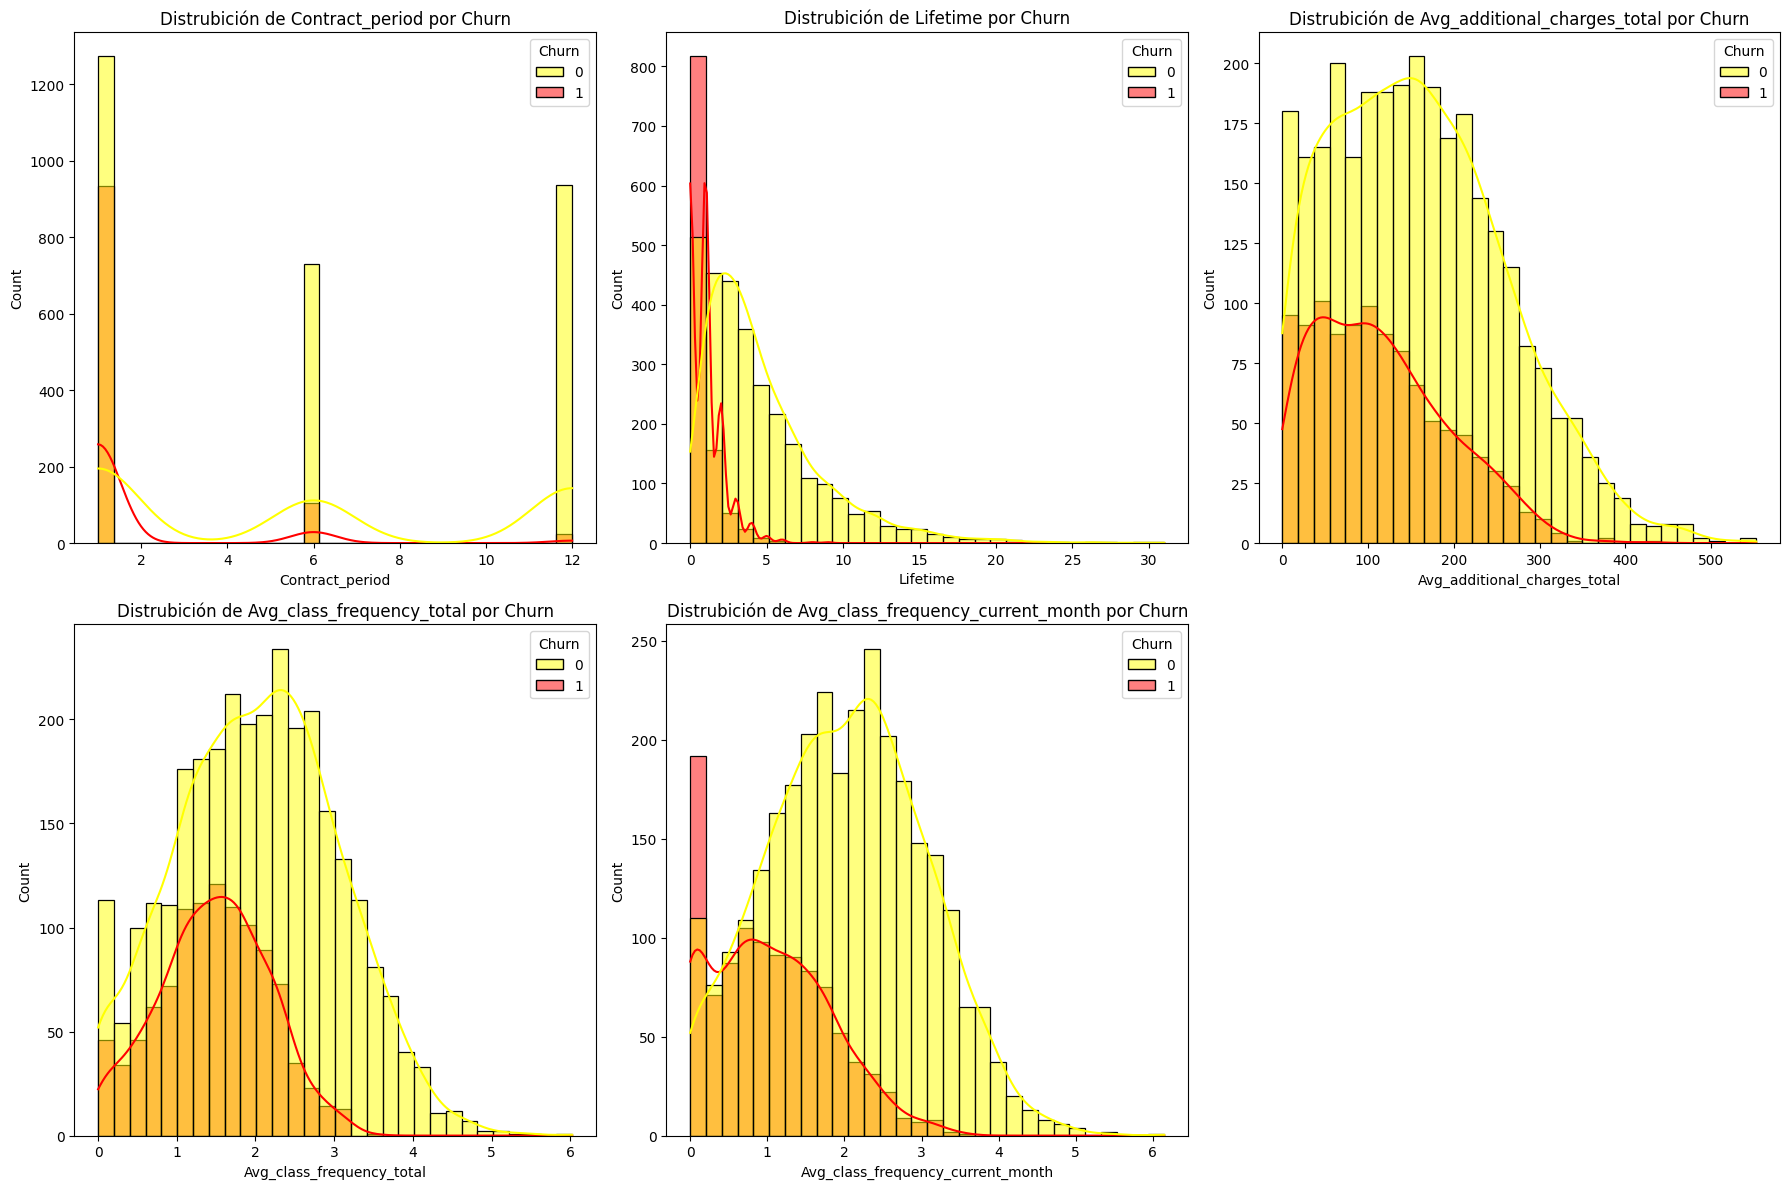

In [14]:
features  = ['Contract_period', 'Lifetime', 'Avg_additional_charges_total', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
fig, axes = plt.subplots(nrows = 2, ncols=3, figsize= (18,12))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(data=gym, x=feature, hue='Churn', kde=True, bins=30, ax=axes[i], palette={0: "yellow", 1:"red"})
    axes[i].set_title(f"Distrubición de {feature} por Churn")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

Excelente, buen trabajo con el despliegue de los histogramas para estudiar las distribuciones de las características sujetas al estado de cancelación de la membresía de los clientes.   </div>

<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
Distribución de Contract_period por Churn: representa la duración del contrato de los clientes en meses. Se observa que la mayoría de los clientes tienen contratos de 1, 6 o 12 meses. Los clientes con contratos cortos (1 mes) tienen una mayor proporción de churn 1, lo que indica que los clientes con contratos más cortos tienen mayor probabilidad de abandonar el servicio. En contratos de 6 y 12 meses, la mayoría de los clientes no cancelan (azul), lo que sugiere que los contratos más largos retienen mejor a los clientes.

Distribución de Lifetime por Churn: representa la cantidad de tiempo que los clientes han permanecido en la empresa. La mayor parte de los clientes que abandonan (rojo) tienen una duración de vida corta, cercana a 0 o 1 meses. Los clientes con mayor permanencia en el servicio tienen menor churn, lo que sugiere que si un cliente supera los primeros meses, es menos probable que cancele.

Distribición de Avg_additional_charges_total por Churn: representa los cargos adicionales promedios de los clientes. Se observa que los clientes con churn (rojo) suelen tener bajos cargos adicionales. Esto puede indicar que los clientes que hacen más gastos adicionales están más comprometidos con el servicio, mientras que los que gastan poco podrían ser más propensos a cancelarlo.

Distribución de Avg_class_frequency_total por Churn: representa la frecuencia promedio de asistencia al gym en toda la permanencia del cliente. Los clientes que asisten con poca frecuencia (cercano a 0-1 clases por periodo) tienen una mayor probabilidad de churn (rojo).
A medida que la asistencia promedio aumenta (más de 2 clases por periodo), el churn disminuye notablemente y la mayoría de los clientes que permanecen (amarillo) tienen frecuencias más altas. Esto sugiere que los clientes que asisten regularmente a clases tienden a quedarse en el servicio.

Distribución de Avg_class_frequency_current_month por Churn:
representa la frecuencia promedio de asistencia en el mes actual. Se observa un patrón similar: los clientes con muy baja asistencia (cercana a 0-1 clases) tienen un churn más alto. Aquellos que asisten con más frecuencia tienen una menor probabilidad de abandonar el servicio. También se nota que hay una concentración de clientes que abandonan en el valor 0, lo que sugiere que algunos dejan de asistir antes de cancelar definitivamente su suscripción.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a>

Has realizado un excelente análisis de la relación entre las variables y el churn. Muy buen trabajo. 



</div>

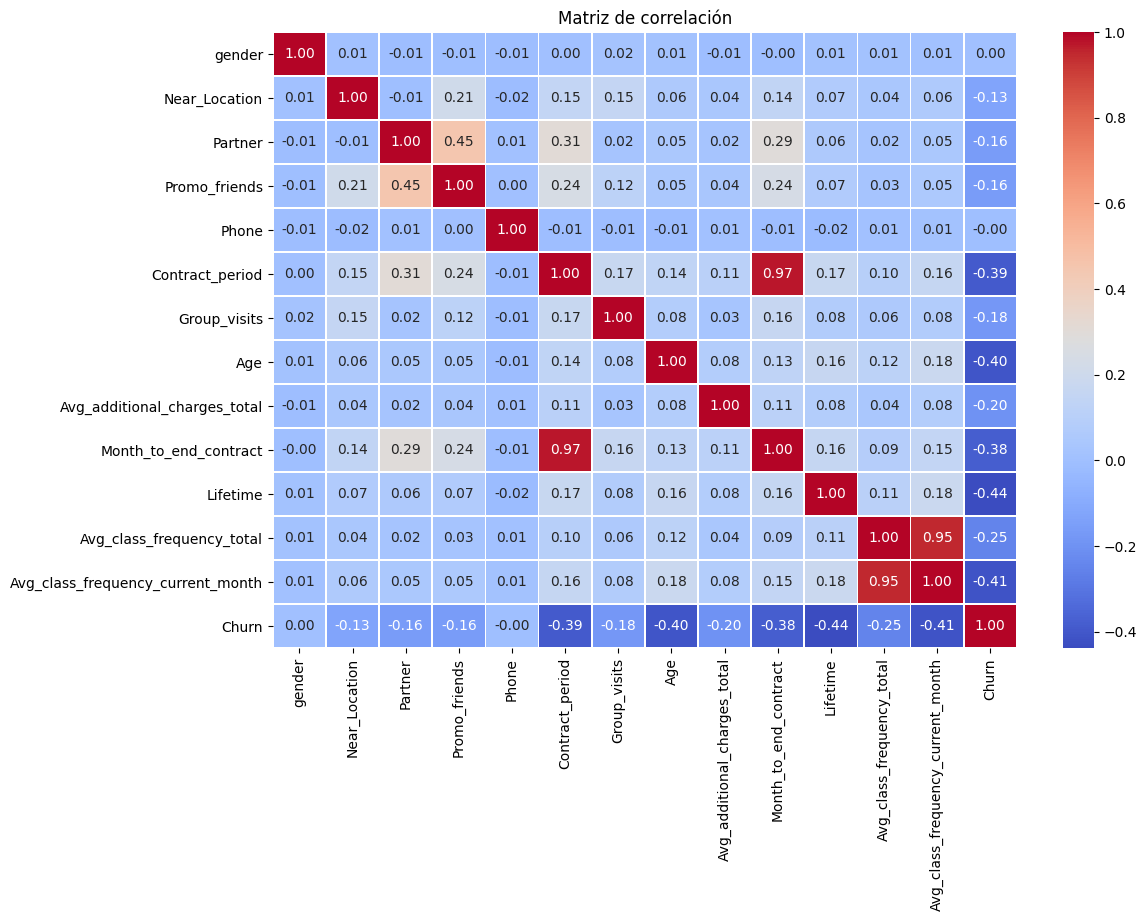

In [15]:
#Matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(gym.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.title('Matriz de correlación')
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a>

Perfecto, buen trabajo desplegando la matriz de correlaciones lineales entre las características y mostrando los resultados en un heatmap. 
</div>

<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
*Variables con mayor correlación*

Edad (-0.40): A mayor edad, menor probabilidad de churn. Parece que los clientes mayores tienden a quedarse más tiempo.

Avg_class_frequency_current_month (-0.41) y Avg_class_frequency_total (-0.25): La frecuencia de asistencia a clases está negativamente correlacionada con el churn. Es decir, los clientes que asisten con más frecuencia tienen menor probabilidad de abandonar.

Contract_period (-0.39) y Month_to_end_contract (-0.38): Un contrato más largo y más meses restantes en el contrato están asociados con una menor tasa de churn.

Lifetime (-0.44): Los clientes con más tiempo en el servicio tienen menor churn.

Contract_period y Month_to_end_contract (0.97): Esto indica que estas variables están fuertemente relacionadas y prácticamente representan lo mismo.

Avg_class_frequency_total y Avg_class_frequency_current_month (0.95): Tiene sentido, ya que alguien con un alto promedio total probablemente también haya asistido con alta frecuencia en el último mes.

Variables como gender, phone, group_visits y additional_charges tienen correlaciones cercanas a 0 con el churn, lo que sugiere que no tienen un impacto significativo.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a>

Perfecto, buen trabajo estudiando las relaciones de pares de variables con más correlación.  
</div>

### Paso 3. Construir un modelo para predecir la cancelación de usuarios

**Dividir los datos en entrenamiento y validación**

In [16]:
# Separar variables predictoras (X) y variable objetivo (y)
X = gym.drop(columns=['Churn'])  # Eliminamos la columna 'Churn' para usar el resto como predictores
y = gym['Churn']  # Variable objetivo

# Dividir el dataset en entrenamiento (80%) y validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<div class="alert alert-block alert-danger"> <b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo realizando el split de los datos. Solo te recomiendo asegurarte de importar todas las librerías al inicio del proyecto para mantener una estructura más organizada y facilitar la lectura del código.

</div>

**Entrenar y evaluar un modelo de Regresión Logística**

In [17]:
# Inicializar y entrenar el modelo
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

# Hacer predicciones en el set de validación
y_pred_log = log_model.predict(X_test)

# Evaluar el modelo
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)

print(f"Regresión Logística - Exactitud: {accuracy_log:.4f}, Precisión: {precision_log:.4f}, Recall: {recall_log:.4f}")


Regresión Logística - Exactitud: 0.9237, Precisión: 0.8756, Recall: 0.8302


<div class="alert alert-block alert-danger"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo desplegando la regresión logística y evaluando los resultados. Únicamente ten en cuenta el tema del importe de las librerías. 

</div>

**Entrenar y evaluar un modelo de Bosque Aleatorio**

In [18]:
# Inicializar y entrenar el modelo
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Hacer predicciones en el set de validación
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Bosque Aleatorio - Exactitud: {accuracy_rf:.4f}, Precisión: {precision_rf:.4f}, Recall: {recall_rf:.4f}")


Bosque Aleatorio - Exactitud: 0.9275, Precisión: 0.8850, Recall: 0.8349


<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
Bosque Aleatorio tiene una mejor precisión (88.38%), lo que significa que comete menos errores al predecir que un usuario cancelará.
Regresión Logística tiene un recall ligeramente mejor (83.02%), lo que indica que detecta más usuarios que realmente cancelan.
La exactitud es casi idéntica en ambos modelos (~92.5%).

<div class="alert alert-block alert-danger"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo desplegando y evaluando el Random Forest. Nuevamente, te recomiendo es tener en cuenta el tema del importe de las librerías. 

</div>

### Paso 4. Crear clústeres de usuarios/as

In [19]:
# Eliminamos la columna 'Churn' ya que no se usa en el clustering
X_cluster = gym.drop(columns=['Churn'])

# Escalamos los datos para que todas las variables tengan la misma importancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


In [ ]:
# Crear la matriz de distancias con el método de enlace 'ward'
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrograma para Identificar Clústeres")
#plt.xlabel("Usuarios")
plt.ylabel("Distancia Euclidiana")
plt.show()

<div class="alert alert-block alert-danger"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo desplegando el dendogramas, ahora bien, en este caso se podría nuevamente tener en cuenta el tema del importe de las librerías y, por otro lado, podrías eliminar los ticks del eje x, ya que si te fijas estos no se logra distinguir de manera correcta por la cantidad de datos que estamos manejando. 

</div>

<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
Hay diferencias claras entre ciertos grupos, lo que sugiere que los clientes tienen patrones de comportamiento distintos.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo con el estudio de los resultados. 

</div>

In [ ]:
# Entrenar K-Means con 5 clústeres
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
gym['Cluster'] = kmeans.fit_predict(X_scaled)

# Ver el número de clientes por clúster
print(gym['Cluster'].value_counts())

<div class="alert alert-block alert-danger"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Buen trabajo desplegando el algoritmo de clustering ``KMeans``, ahora bien, ten en cuenta el tema del importe de las librerías. 

</div>

In [ ]:
#Valores medios por cada Clúster
# Obtener valores medios de cada grupo
cluster_means = gym.groupby('Cluster').mean()
print("\nValores medios por clúster:")
print(cluster_means)


<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">
Clúster 3 y 0 tienen la mayor tasa de cancelación,
Clúster 1 es el más leal,
Clúster 4 Usuarios con más tiempo en el gimnasio y mayor frecuencia de visitas.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Excelente, buen trabajo estudiando los valores medios de las características sujetos a los clusters creados. 
</div>

In [ ]:
#Visualizar las distribuciones por clúster

features = ['Lifetime', 'Avg_additional_charges_total', 'Avg_class_frequency_total', 'Contract_period']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Cluster', y=feature, data=gym, hue="Cluster", palette="Set2", legend=False)
    plt.title(f'Distribución de {feature} por Clúster')

plt.tight_layout()
plt.show()


<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">

**Distribución de Lifetime por Cluster**

El Clúster 4 tiene la mayor mediana y variabilidad, con varios valores atípicos altos.
El Clúster 3 tiene la menor mediana, indicando usuarios con menor tiempo de permanencia.
Clústeres 0, 1 y 2 tienen distribuciones similares con medianas cercanas.

**Avg_additional_charges_total por Clúster**

Los clústeres 1 y 4 tienen la mediana más alta, lo que indica que estos usuarios gastan más en cargos adicionales.
Todos los clústeres tienen valores atípicos con altos gastos.

**Avg_class_frequency_total por Clúster**

El Clúster 4 tiene la mediana más alta, indicando que estos usuarios asisten con mayor frecuencia a clases.
El Clúster 3 tiene la mediana más baja, lo que refuerza la hipótesis de que son clientes menos comprometidos.

**Contract_period por Clúster**

El Clúster 1 tiene el período de contrato más largo (mediana de casi 12 meses).
Clústeres 3 y 0 tienen los períodos más cortos, lo que sugiere que son clientes menos comprometidos.


<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Perfecto, buen trabajo desplegando y estudiando los boxplots de las características sujetas a los clusters creados. 
</div>

In [ ]:
# Calcular la tasa de cancelación para cada clúster
churn_rate = gym.groupby('Cluster')['Churn'].mean()
print("\nTasa de cancelación por clúster:")
print(churn_rate)

<div class="alert alert-block" style="background-color: #D8BFD8; color: #374151;">

**Clúster 3 tiene la tasa de cancelación más alta (52.66%)**

Coincide con lo observado en los gráficos:
Menor "Lifetime"
Menor frecuencia de asistencia a clases
Contrato más corto
Interpretación: Son clientes de bajo compromiso que podrían estar en su período de prueba o no ven valor en el servicio.

**Clúster 0 también tiene una tasa alta (45.04%)**

Aunque es menor que el Clúster 3, sigue siendo preocupante.
Estos clientes tienen una asistencia media a clases y contratos cortos.
Interpretación: Es un grupo con menos compromiso, pero con potencial de retención si se aplican estrategias adecuadas.

**Clúster 2 tiene una tasa de cancelación moderada (24.61%)**

Mayor uso de promociones y mayor cercanía al gimnasio que los Clústeres 0 y 3.
Interpretación: Aunque hay clientes que abandonan, este grupo podría beneficiarse con incentivos.

**Clústeres 1 y 4 tienen tasas de cancelación muy bajas (2.24% y 6.91%)**

Estos clientes tienen contratos más largos y gastan más en cargos adicionales.
Interpretación: Son clientes altamente leales y comprometidos.


<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Perfecto, buen trabajo estudiando la tasa de cancelación por cluster.  
</div>

### Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

#### Conclusiones y Recomendaciones Básicas para la Retención de Clientes

Existen clientes altamente comprometidos y otros con alto riesgo de cancelación.

Clústeres 1 y 4 muestran fidelidad, mientras que Clústeres 0 y 3 tienen una alta tasa de churn.
La duración del contrato y la frecuencia de asistencia influyen en la retención.

Contratos más largos y mayor frecuencia de uso están asociados con menor churn.
Los clientes con alto churn podrían beneficiarse de estrategias de engagement.

Aquellos con contratos cortos o baja asistencia requieren incentivos para mantenerse activos.


**Recomendaciones Estratégicas:**

1. Implementar programas de fidelización

Ofrecer descuentos o beneficios exclusivos a clientes con más de 6 meses de membresía.
Crear un sistema de recompensas basado en asistencia frecuente.

2. Mejorar la retención de clientes con alto churn

Enviar recordatorios personalizados para asistir a clases.
Ofrecer pruebas gratuitas de servicios adicionales.
Extender promociones para clientes con contratos cortos.

3. Diseñar membresías personalizadas

Adaptar planes según el uso y necesidades del cliente.
Ofrecer membresías premium con beneficios exclusivos para Clústeres 1 y 4.

4. Utilizar marketing dirigido y comunicación efectiva

Campañas de email/WhatsApp con ofertas personalizadas.
Encuestas a clientes con alto churn para identificar áreas de mejora.
Publicidad enfocada en beneficios clave según cada clúster.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Muy buen trabajo. </div>